## Učitavanje biblioteka i podešavanje okruženja

In [1]:
from pathlib import Path

import emotion_utils
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import classification_report
from torch.nn.utils.rnn import pack_padded_sequence

from emotion_utils import (
    PAD_IDX,
    get_device,
    plot_history,
    prepare_emotion_data,
    print_evaluation,
    set_seed,
    train_model,
)

SEED = 7
RESULTS_DIR = (
    Path(emotion_utils.__file__).resolve().parent.parent / 'results' / 'LSTM'
)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
set_seed(SEED)
device = get_device()
print(f'Device: {device}')

Device: cpu


## Učitavanje i priprema podataka

In [2]:
data = prepare_emotion_data(seed=SEED)

train_loader = data.train_loader
val_loader = data.val_loader
test_loader = data.test_loader
label_names = data.label_names

print(f'Trening:    {len(data.train_texts):>5} primera')
print(f'Validacija: {len(data.val_texts):>5} primera')
print(f'Test:       {len(data.test_texts):>5} primera')
print(f'Broj različitih tokena u trening skupu: {len(data.token_counts)}')
print(f'Veličina rečnika sa posebnim tokenima: {len(data.index_to_token)}')
print('Klase:', data.label_to_index)

example_ids = data.encode(data.train_texts[0])
example_inputs, example_lengths, _ = next(iter(train_loader))
print('Niz indeksa:', example_ids)
print('Oblik batch tenzora posle padding-a:', example_inputs.shape)
print('Dužine prvih pet sekvenci:', example_lengths[:5].tolist())

Trening:    15983 primera
Validacija:  1997 primera
Test:        2000 primera
Broj različitih tokena u trening skupu: 15202
Veličina rečnika sa posebnim tokenima: 7397
Klase: {'anger': 0, 'fear': 1, 'joy': 2, 'love': 3, 'sadness': 4, 'surprise': 5}
Niz indeksa: [2, 139, 3, 679]
Oblik batch tenzora posle padding-a: torch.Size([128, 46])
Dužine prvih pet sekvenci: [14, 16, 37, 13, 6]


## LSTM model

In [3]:
class LSTMClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_size,
        num_classes,
        padding_idx,
        num_layers=1,
        dropout=0.3,
    ):
        super().__init__()
        self.embedding = nn.Embedding(
            vocab_size, embedding_dim, padding_idx=padding_idx
        )
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, token_ids, lengths):
        embedded = self.embedding(token_ids)
        packed = pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, (hidden, _) = self.lstm(packed)
        final_hidden = hidden[-1]
        return self.classifier(self.dropout(final_hidden))


def create_model(config):
    return LSTMClassifier(
        vocab_size=len(data.index_to_token),
        embedding_dim=config['embedding_dim'],
        hidden_size=config['hidden_size'],
        num_classes=len(label_names),
        padding_idx=PAD_IDX,
        num_layers=config['num_layers'],
        dropout=config['dropout'],
    ).to(device)

## Trening 20 konfiguracija

In [4]:
EPOCHS = 10

# Deset arhitektura x dve stope učenja = tačno 20 kombinacija.
architectures = [
    {'embedding_dim': 32, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2},
    {'embedding_dim': 32, 'hidden_size': 64, 'num_layers': 2, 'dropout': 0.2},
    {'embedding_dim': 32, 'hidden_size': 128, 'num_layers': 1, 'dropout': 0.3},
    {'embedding_dim': 32, 'hidden_size': 128, 'num_layers': 2, 'dropout': 0.3},
    {'embedding_dim': 64, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2},
    {'embedding_dim': 64, 'hidden_size': 64, 'num_layers': 2, 'dropout': 0.4},
    {'embedding_dim': 64, 'hidden_size': 128, 'num_layers': 1, 'dropout': 0.3},
    {'embedding_dim': 64, 'hidden_size': 128, 'num_layers': 2, 'dropout': 0.4},
    {'embedding_dim': 128, 'hidden_size': 128, 'num_layers': 1, 'dropout': 0.3},
    {'embedding_dim': 128, 'hidden_size': 256, 'num_layers': 2, 'dropout': 0.5},
]
learning_rates = [5e-4, 1e-3]

experiment_configs = []
for architecture in architectures:
    for learning_rate in learning_rates:
        experiment_configs.append({**architecture, 'learning_rate': learning_rate})

assert len(experiment_configs) == 20

experiment_models = {}
experiment_histories = {}
experiment_results = []

for experiment_number, config in enumerate(experiment_configs, start=1):
    experiment_name = f'LSTM_{experiment_number:02d}'
    print(f'\n{"=" * 80}\n{experiment_name}: {config}')

    # Ista inicijalna slučajnost i isti redosled batch-eva za svaku konfiguraciju.
    set_seed(SEED)
    if train_loader.generator is not None:
        train_loader.generator.manual_seed(SEED)

    current_model = create_model(config)
    current_history = train_model(
        current_model,
        train_loader,
        val_loader,
        device=device,
        epochs=EPOCHS,
        learning_rate=config['learning_rate'],
    )

    best_epoch_index = min(
        range(EPOCHS), key=lambda index: current_history['val_loss'][index]
    )
    experiment_histories[experiment_name] = current_history
    experiment_models[experiment_name] = current_model.to('cpu')
    experiment_results.append({
        'name': experiment_name,
        **config,
        'best_epoch': best_epoch_index + 1,
        'best_val_loss': current_history['val_loss'][best_epoch_index],
        'val_accuracy_at_best_loss': current_history['val_accuracy'][best_epoch_index],
        'max_val_accuracy': max(current_history['val_accuracy']),
    })

    if device.type == 'cuda':
        torch.cuda.empty_cache()

ranked_results = sorted(experiment_results, key=lambda row: row['best_val_loss'])
pd.DataFrame(ranked_results).to_csv(
    RESULTS_DIR / 'lstm_tuning_results.csv', index=False
)

print('\nRangiranje po najmanjem validacionom loss-u:')
print(
    f'{"Model":<9} {"Emb":>4} {"Hidden":>6} {"Slojevi":>7} ' 
    f'{"Dropout":>8} {"LR":>8} {"Epoha":>6} {"Val loss":>10} {"Val acc":>9}'
)
for result in ranked_results:
    print(
        f'{result["name"]:<9} {result["embedding_dim"]:>4} '
        f'{result["hidden_size"]:>6} {result["num_layers"]:>7} '
        f'{result["dropout"]:>8.2f} {result["learning_rate"]:>8.1e} '
        f'{result["best_epoch"]:>6} {result["best_val_loss"]:>10.4f} '
        f'{result["val_accuracy_at_best_loss"]:>9.4f}'
    )

# Zadržavamo i standardna imena model/history za naredne ćelije.
best_result = ranked_results[0]
best_model_name = best_result['name']
model = experiment_models[best_model_name].to(device)
history = experiment_histories[best_model_name]
print(f'\nNajbolji model: {best_model_name} ({best_result})')


LSTM_01: {'embedding_dim': 32, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2, 'learning_rate': 0.0005}


Epohe:   0%|          | 0/10 [00:00<?, ?it/s]

Epoha 01 | train loss: 1.6430, train acc: 0.3151 | val loss: 1.5811, val acc: 0.3540
Epoha 02 | train loss: 1.5698, train acc: 0.3436 | val loss: 1.5687, val acc: 0.3560
Epoha 03 | train loss: 1.5514, train acc: 0.3639 | val loss: 1.5540, val acc: 0.3716
Epoha 04 | train loss: 1.5180, train acc: 0.3903 | val loss: 1.5126, val acc: 0.4061
Epoha 05 | train loss: 1.4627, train acc: 0.4218 | val loss: 1.4556, val acc: 0.4472
Epoha 06 | train loss: 1.3717, train acc: 0.4783 | val loss: 1.3730, val acc: 0.4807
Epoha 07 | train loss: 1.2721, train acc: 0.5319 | val loss: 1.3078, val acc: 0.5263
Epoha 08 | train loss: 1.1643, train acc: 0.5844 | val loss: 1.2037, val acc: 0.5709
Epoha 09 | train loss: 1.0610, train acc: 0.6276 | val loss: 1.1559, val acc: 0.5904
Epoha 10 | train loss: 0.9695, train acc: 0.6620 | val loss: 1.0618, val acc: 0.6269

LSTM_02: {'embedding_dim': 32, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2, 'learning_rate': 0.001}


Epohe:   0%|          | 0/10 [00:00<?, ?it/s]

Epoha 01 | train loss: 1.6124, train acc: 0.3279 | val loss: 1.5739, val acc: 0.3455
Epoha 02 | train loss: 1.5501, train acc: 0.3648 | val loss: 1.5358, val acc: 0.3876
Epoha 03 | train loss: 1.4664, train acc: 0.4227 | val loss: 1.4527, val acc: 0.4512
Epoha 04 | train loss: 1.2807, train acc: 0.5272 | val loss: 1.2286, val acc: 0.5699
Epoha 05 | train loss: 1.0492, train acc: 0.6339 | val loss: 1.0532, val acc: 0.6355
Epoha 06 | train loss: 0.8383, train acc: 0.7114 | val loss: 0.8876, val acc: 0.6910
Epoha 07 | train loss: 0.6838, train acc: 0.7679 | val loss: 0.7893, val acc: 0.7186
Epoha 08 | train loss: 0.5672, train acc: 0.8117 | val loss: 0.6704, val acc: 0.7707
Epoha 09 | train loss: 0.4667, train acc: 0.8443 | val loss: 0.5954, val acc: 0.7987
Epoha 10 | train loss: 0.3870, train acc: 0.8713 | val loss: 0.5416, val acc: 0.8227

LSTM_03: {'embedding_dim': 32, 'hidden_size': 64, 'num_layers': 2, 'dropout': 0.2, 'learning_rate': 0.0005}


...

Epoha 01 | train loss: 1.5735, train acc: 0.3710 | val loss: 1.5028, val acc: 0.4231
Epoha 02 | train loss: 1.2771, train acc: 0.5352 | val loss: 1.0716, val acc: 0.6244
Epoha 03 | train loss: 0.7880, train acc: 0.7354 | val loss: 0.7217, val acc: 0.7541
Epoha 04 | train loss: 0.4762, train acc: 0.8465 | val loss: 0.5183, val acc: 0.8262
Epoha 05 | train loss: 0.3037, train acc: 0.9017 | val loss: 0.4018, val acc: 0.8758
Epoha 06 | train loss: 0.2045, train acc: 0.9334 | val loss: 0.3645, val acc: 0.8883
Epoha 07 | train loss: 0.1425, train acc: 0.9526 | val loss: 0.3246, val acc: 0.9029
Epoha 08 | train loss: 0.1061, train acc: 0.9645 | val loss: 0.3301, val acc: 0.8993
Epoha 09 | train loss: 0.0803, train acc: 0.9733 | val loss: 0.3460, val acc: 0.9059
Epoha 10 | train loss: 0.0681, train acc: 0.9761 | val loss: 0.3269, val acc: 0.9044

LSTM_19: {'embedding_dim': 128, 'hidden_size': 256, 'num_layers': 2, 'dropout': 0.5, 'learning_rate': 0.0005}


Epohe:   0%|          | 0/10 [00:00<?, ?it/s]

Epoha 01 | train loss: 1.5816, train acc: 0.3456 | val loss: 1.5255, val acc: 0.3901
Epoha 02 | train loss: 1.3687, train acc: 0.4804 | val loss: 1.2227, val acc: 0.5488
Epoha 03 | train loss: 0.9822, train acc: 0.6595 | val loss: 0.9406, val acc: 0.6700
Epoha 04 | train loss: 0.6941, train acc: 0.7648 | val loss: 0.6925, val acc: 0.7702
Epoha 05 | train loss: 0.4936, train acc: 0.8376 | val loss: 0.5837, val acc: 0.8057
Epoha 06 | train loss: 0.3650, train acc: 0.8771 | val loss: 0.5235, val acc: 0.8282
Epoha 07 | train loss: 0.2809, train acc: 0.9073 | val loss: 0.4800, val acc: 0.8523
Epoha 08 | train loss: 0.2241, train acc: 0.9230 | val loss: 0.4450, val acc: 0.8663
Epoha 09 | train loss: 0.1791, train acc: 0.9401 | val loss: 0.4018, val acc: 0.8843
Epoha 10 | train loss: 0.1435, train acc: 0.9487 | val loss: 0.3746, val acc: 0.8898

LSTM_20: {'embedding_dim': 128, 'hidden_size': 256, 'num_layers': 2, 'dropout': 0.5, 'learning_rate': 0.001}


Epohe:   0%|          | 0/10 [00:00<?, ?it/s]

Epoha 01 | train loss: 1.5416, train acc: 0.3748 | val loss: 1.3955, val acc: 0.4727
Epoha 02 | train loss: 1.0574, train acc: 0.6249 | val loss: 0.8280, val acc: 0.7196
Epoha 03 | train loss: 0.5765, train acc: 0.8092 | val loss: 0.5252, val acc: 0.8197
Epoha 04 | train loss: 0.3310, train acc: 0.8926 | val loss: 0.4078, val acc: 0.8568
Epoha 05 | train loss: 0.2125, train acc: 0.9276 | val loss: 0.3187, val acc: 0.8918
Epoha 06 | train loss: 0.1542, train acc: 0.9433 | val loss: 0.3117, val acc: 0.8993
Epoha 07 | train loss: 0.1191, train acc: 0.9551 | val loss: 0.2740, val acc: 0.9119
Epoha 08 | train loss: 0.0938, train acc: 0.9655 | val loss: 0.3344, val acc: 0.9009
Epoha 09 | train loss: 0.0722, train acc: 0.9743 | val loss: 0.3095, val acc: 0.9079
Epoha 10 | train loss: 0.0637, train acc: 0.9761 | val loss: 0.3376, val acc: 0.9069

Rangiranje po najmanjem validacionom loss-u:
Model      Emb Hidden Slojevi  Dropout       LR  Epoha   Val loss   Val acc
LSTM_20    128    256       

LSTM_20 | emb=128, hidden=256, layers=2, dropout=0.5, lr=0.001


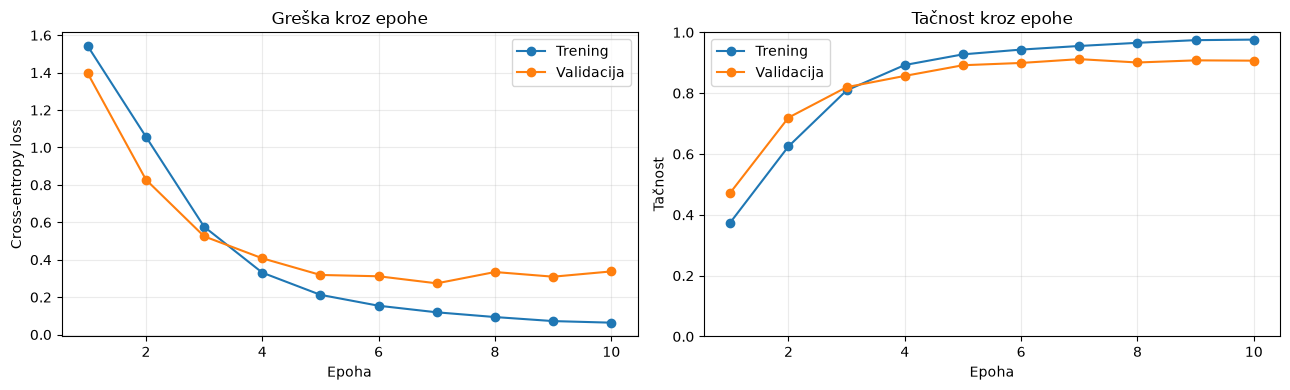

LSTM_18 | emb=128, hidden=128, layers=1, dropout=0.3, lr=0.001


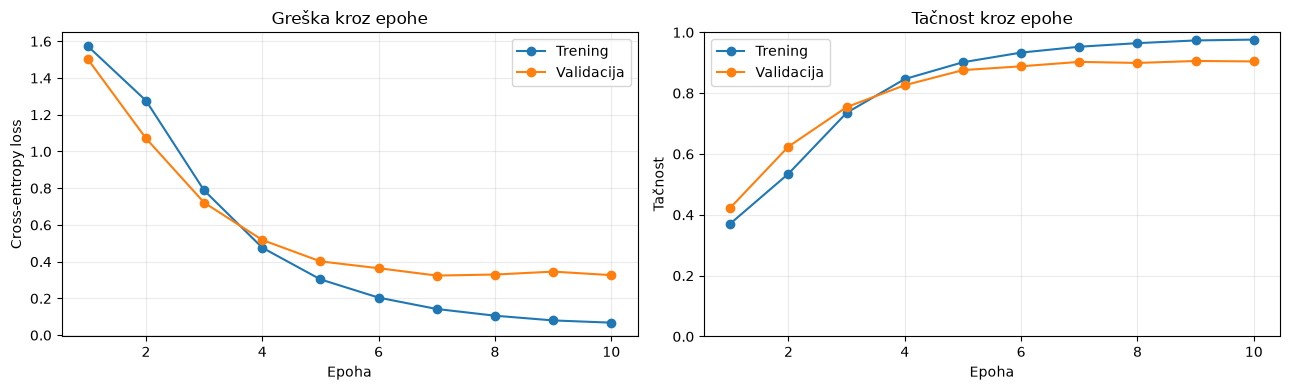

LSTM_14 | emb=64, hidden=128, layers=1, dropout=0.3, lr=0.001


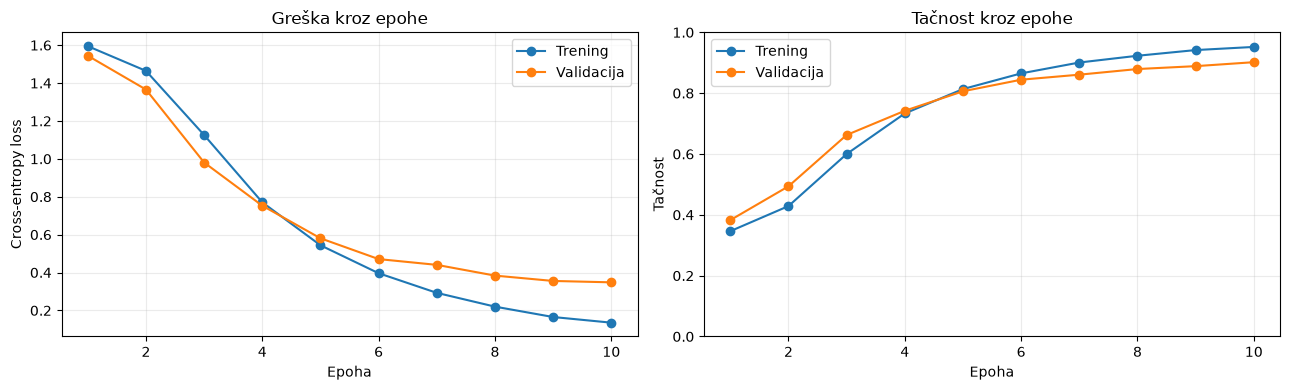

LSTM_16 | emb=64, hidden=128, layers=2, dropout=0.4, lr=0.001


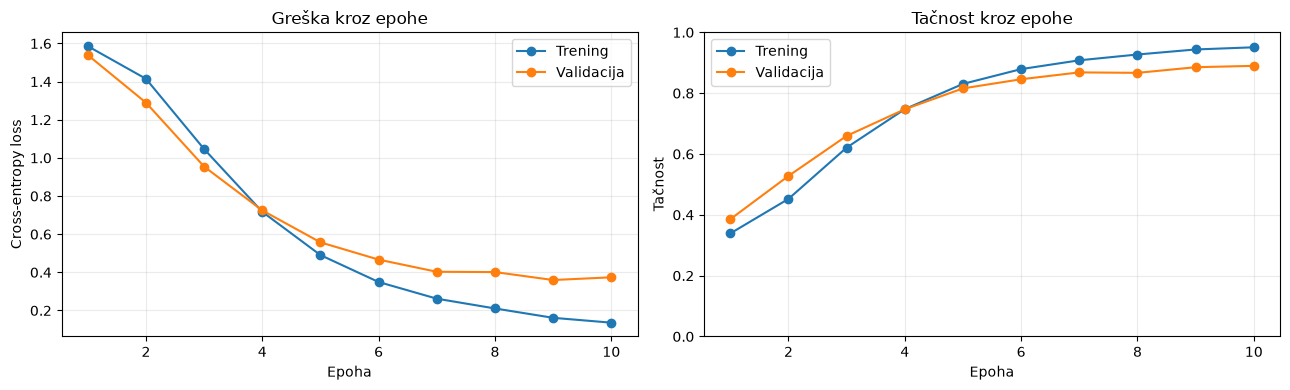

LSTM_19 | emb=128, hidden=256, layers=2, dropout=0.5, lr=0.0005


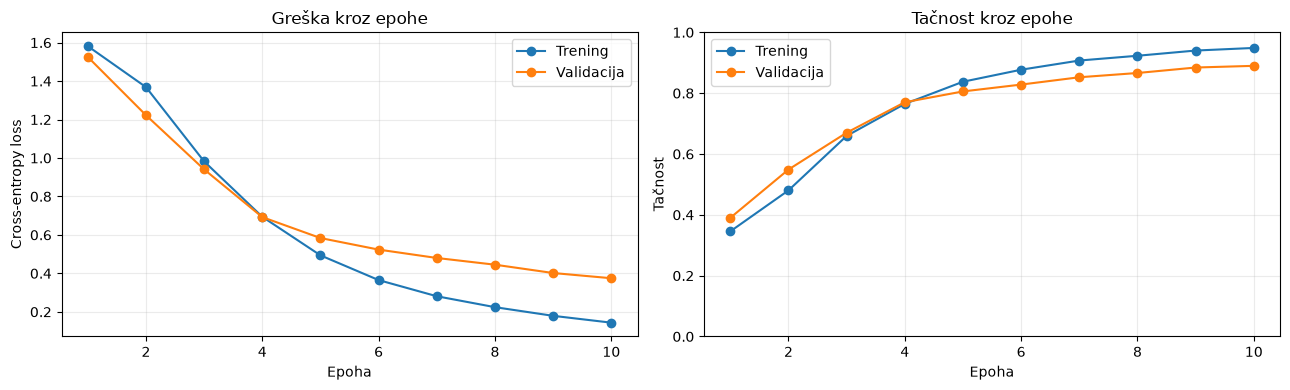

LSTM_06 | emb=32, hidden=128, layers=1, dropout=0.3, lr=0.001


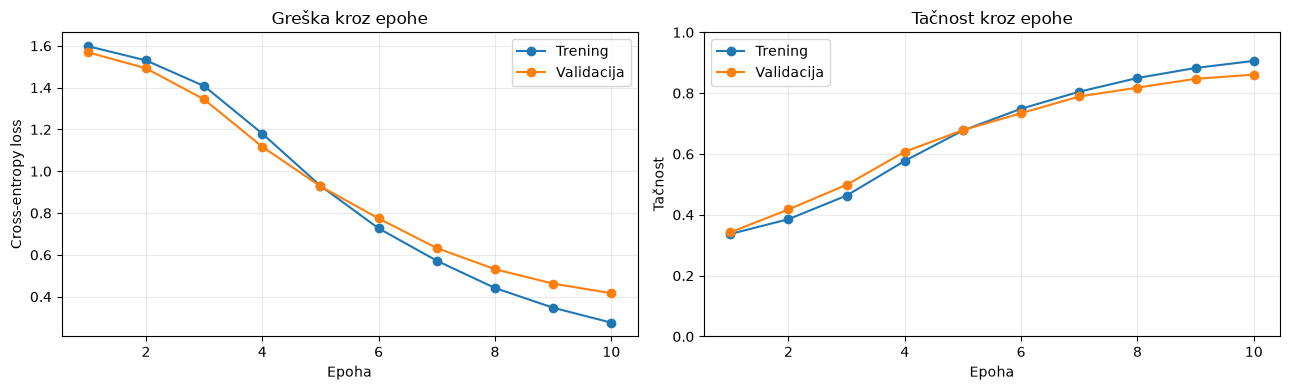

LSTM_12 | emb=64, hidden=64, layers=2, dropout=0.4, lr=0.001


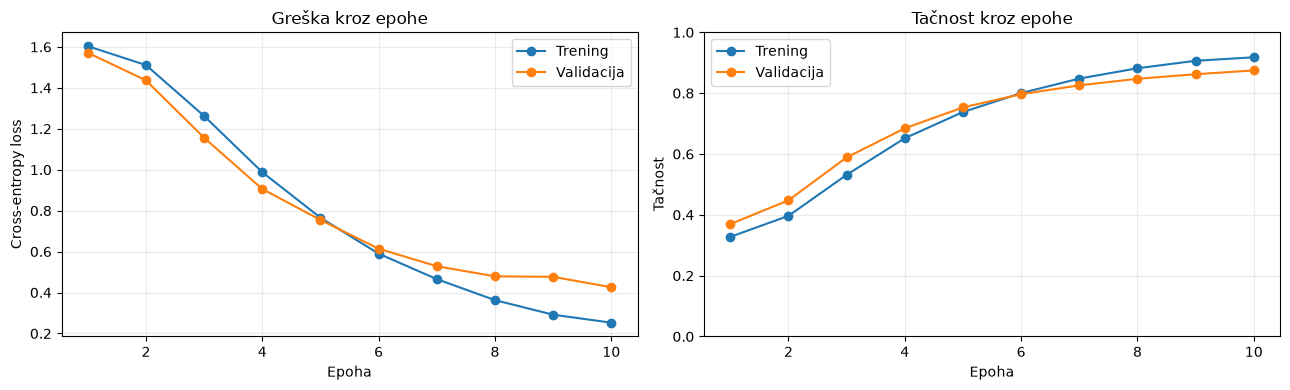

LSTM_08 | emb=32, hidden=128, layers=2, dropout=0.3, lr=0.001


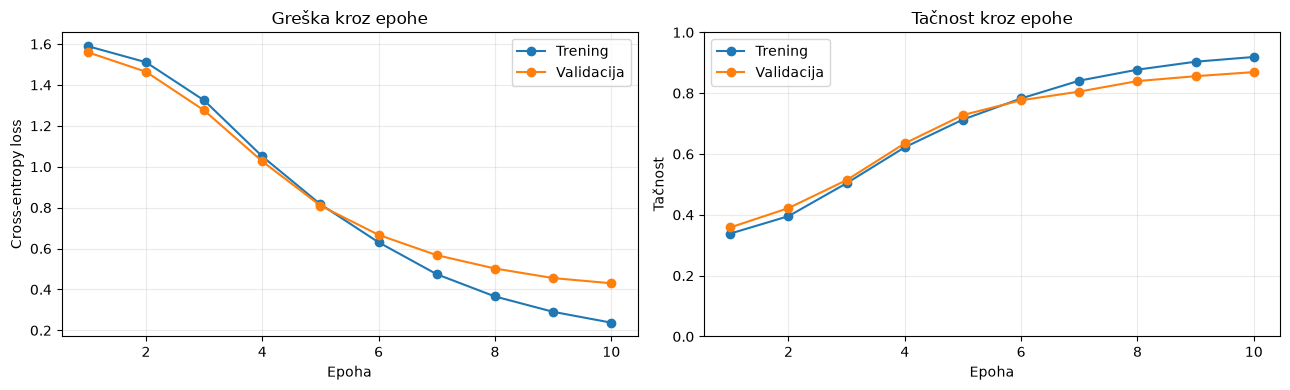

LSTM_10 | emb=64, hidden=64, layers=1, dropout=0.2, lr=0.001


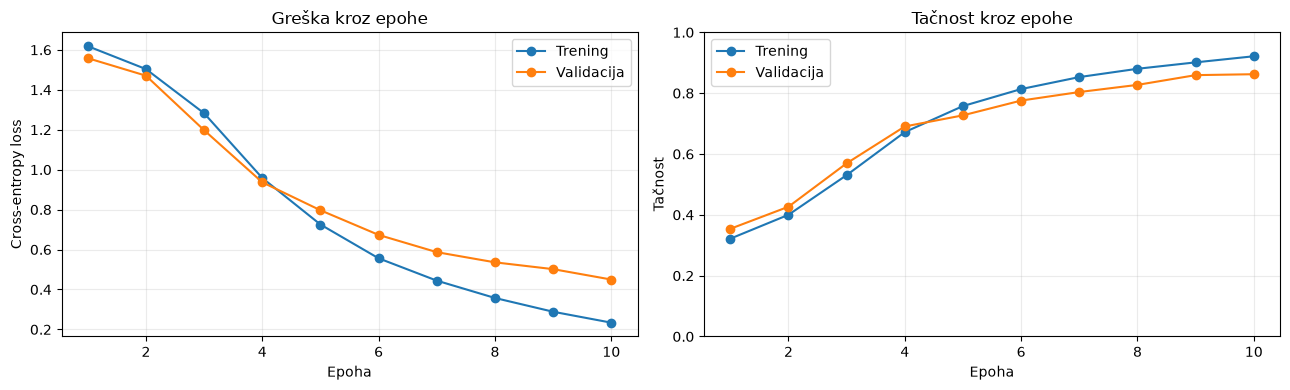

LSTM_17 | emb=128, hidden=128, layers=1, dropout=0.3, lr=0.0005


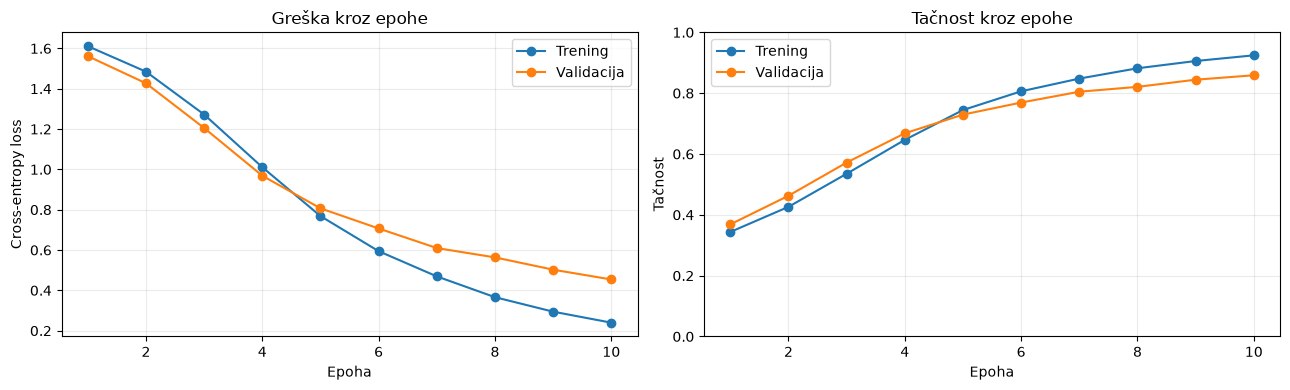

LSTM_04 | emb=32, hidden=64, layers=2, dropout=0.2, lr=0.001


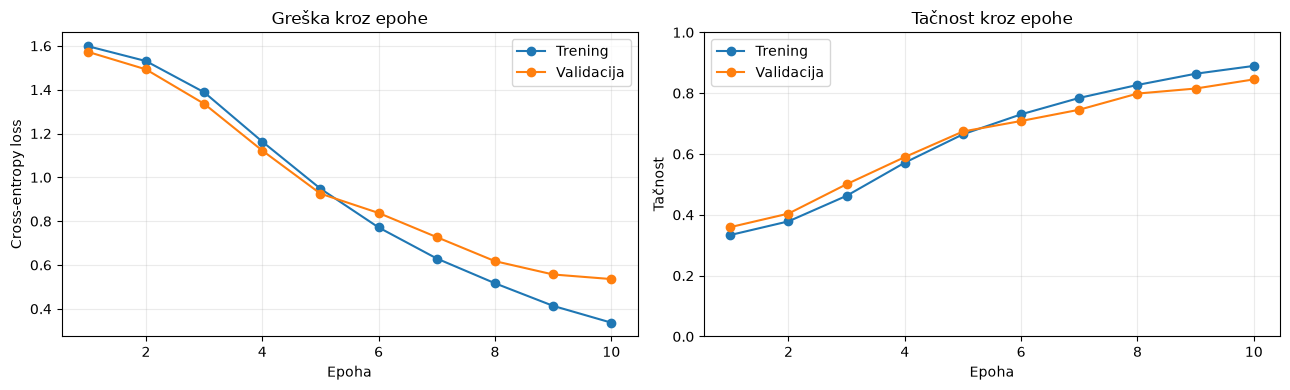

LSTM_02 | emb=32, hidden=64, layers=1, dropout=0.2, lr=0.001


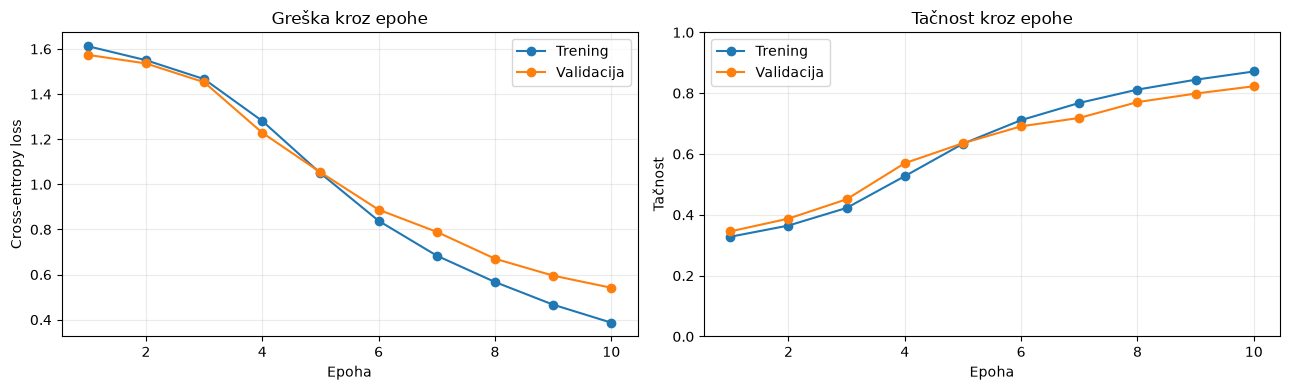

LSTM_15 | emb=64, hidden=128, layers=2, dropout=0.4, lr=0.0005


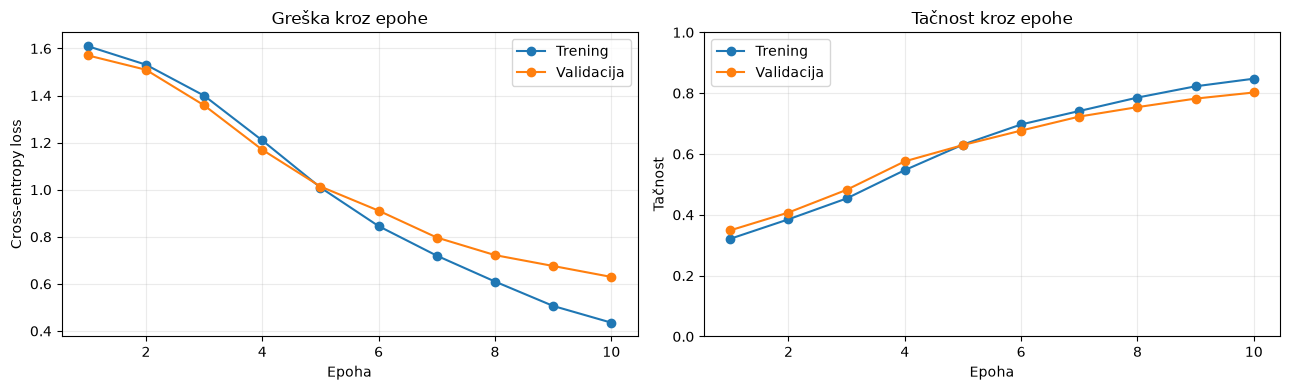

LSTM_13 | emb=64, hidden=128, layers=1, dropout=0.3, lr=0.0005


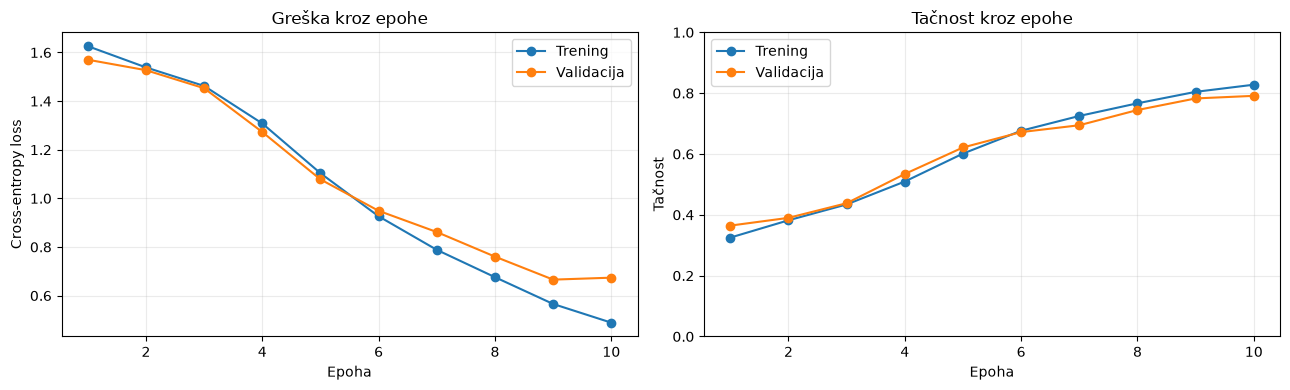

LSTM_09 | emb=64, hidden=64, layers=1, dropout=0.2, lr=0.0005


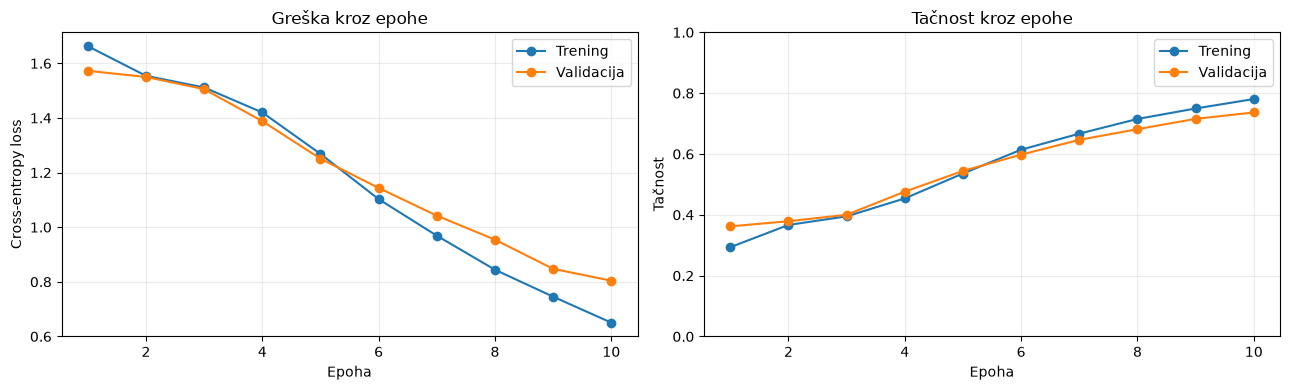

LSTM_11 | emb=64, hidden=64, layers=2, dropout=0.4, lr=0.0005


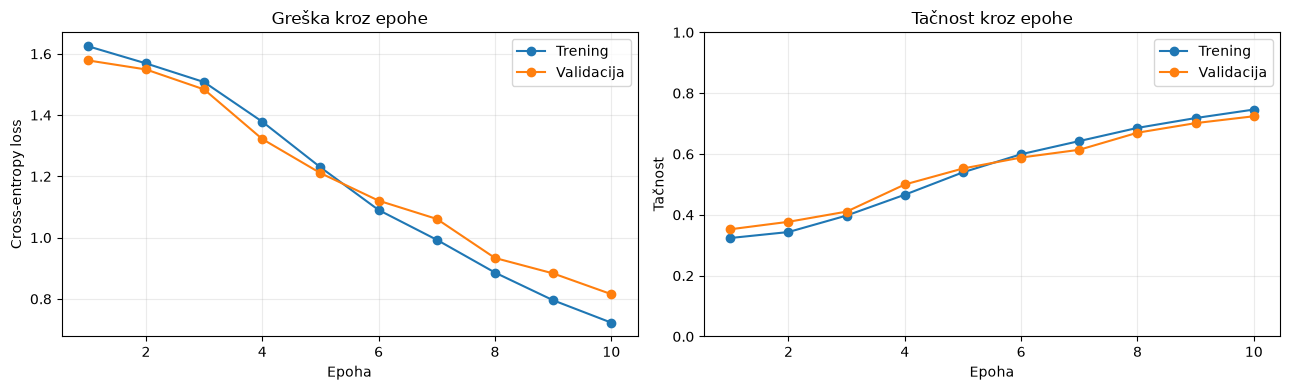

LSTM_07 | emb=32, hidden=128, layers=2, dropout=0.3, lr=0.0005


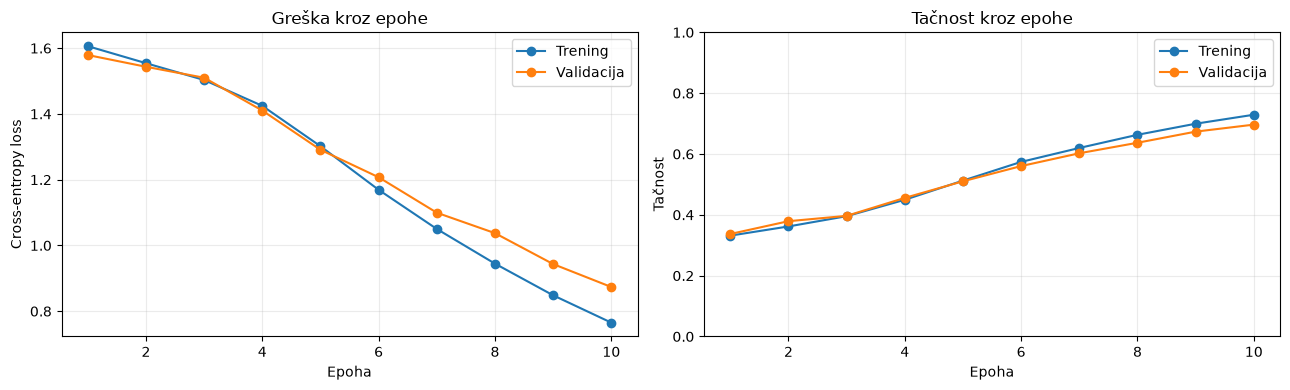

LSTM_05 | emb=32, hidden=128, layers=1, dropout=0.3, lr=0.0005


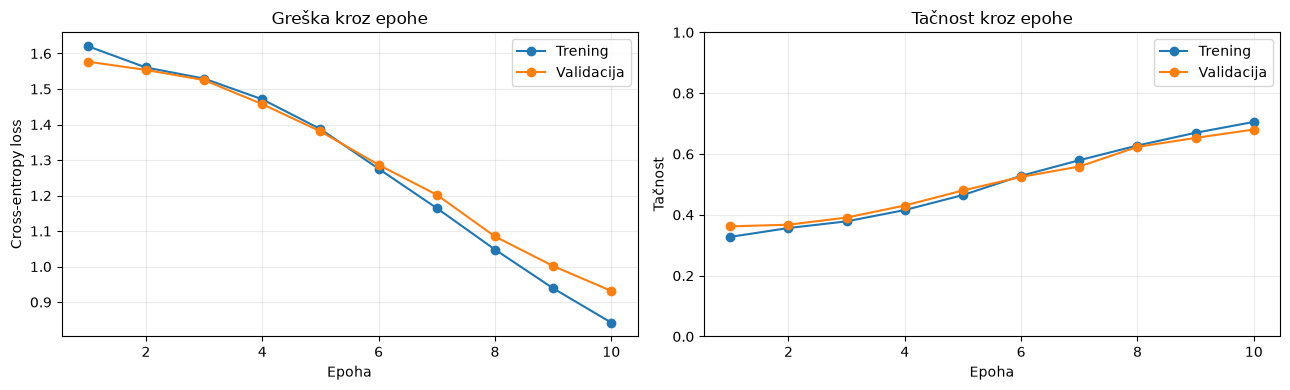

LSTM_03 | emb=32, hidden=64, layers=2, dropout=0.2, lr=0.0005


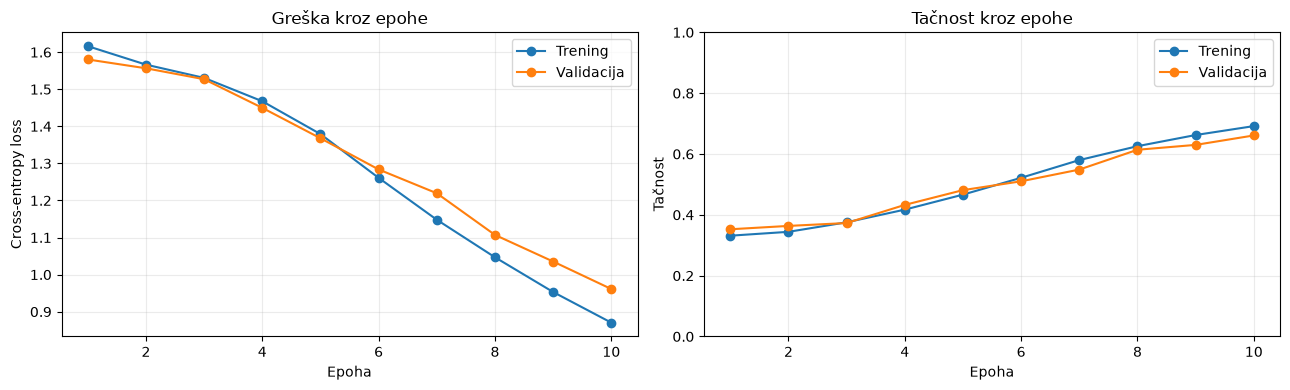

LSTM_01 | emb=32, hidden=64, layers=1, dropout=0.2, lr=0.0005


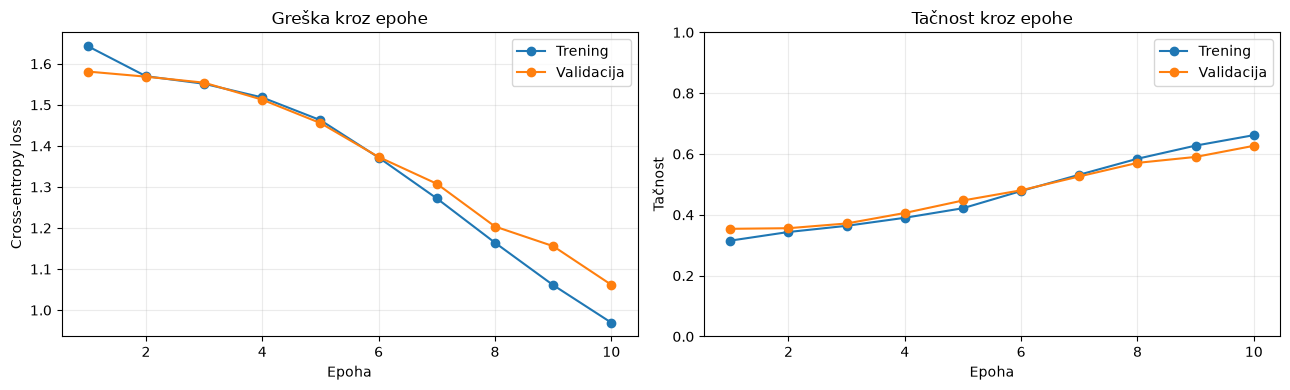

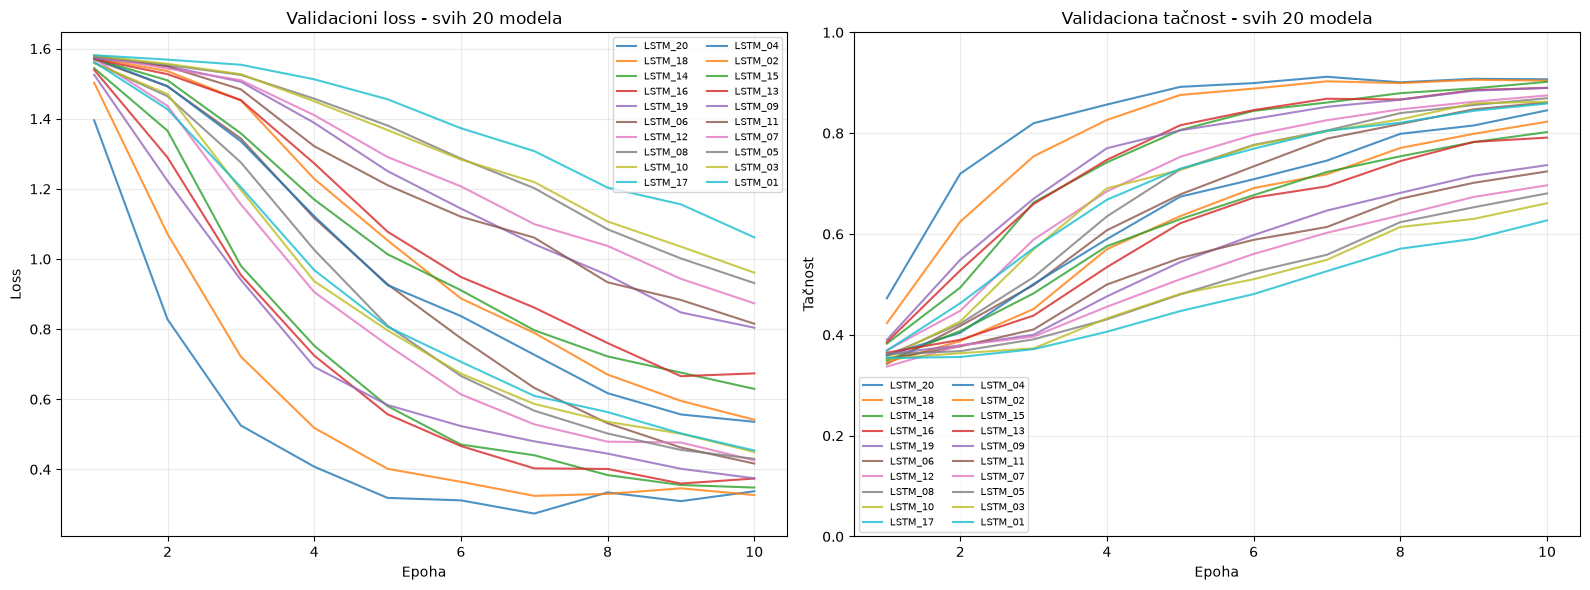

In [5]:
# Isti prikaz kao originalni plot_history, jednom za svaku konfiguraciju.
PLOT_EACH_HISTORY = True

if PLOT_EACH_HISTORY:
    for result in ranked_results:
        name = result['name']
        print(
            f'{name} | emb={result["embedding_dim"]}, '
            f'hidden={result["hidden_size"]}, layers={result["num_layers"]}, '
            f'dropout={result["dropout"]}, lr={result["learning_rate"]}'
        )
        plot_history(experiment_histories[name])

# Zajednički pregled validacionih krivih svih 20 modela.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for result in ranked_results:
    name = result['name']
    current_history = experiment_histories[name]
    epochs = range(1, len(current_history['val_loss']) + 1)
    axes[0].plot(epochs, current_history['val_loss'], label=name, alpha=0.8)
    axes[1].plot(epochs, current_history['val_accuracy'], label=name, alpha=0.8)

axes[0].set(title='Validacioni loss - svih 20 modela', xlabel='Epoha', ylabel='Loss')
axes[1].set(
    title='Validaciona tačnost - svih 20 modela',
    xlabel='Epoha',
    ylabel='Tačnost',
    ylim=(0, 1),
)
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend(ncol=2, fontsize=7)
plt.tight_layout()
plt.show()

## Evaluacija modela

Evaluacija najboljeg modela: LSTM_20
Parametri: {'embedding_dim': 128, 'hidden_size': 256, 'num_layers': 2, 'dropout': 0.5, 'learning_rate': 0.001}


Evaluacija:   0%|          | 0/16 [00:00<?, ?it/s]

Test greška:  0.2950
Test tačnost: 0.9035

              precision    recall  f1-score   support

       anger     0.8881    0.8945    0.8913       275
        fear     0.8534    0.8839    0.8684       224
         joy     0.9274    0.9194    0.9234       695
        love     0.7733    0.8365    0.8036       159
     sadness     0.9462    0.9380    0.9421       581
    surprise     0.8519    0.6970    0.7667        66

    accuracy                         0.9035      2000
   macro avg     0.8734    0.8616    0.8659      2000
weighted avg     0.9044    0.9035    0.9036      2000



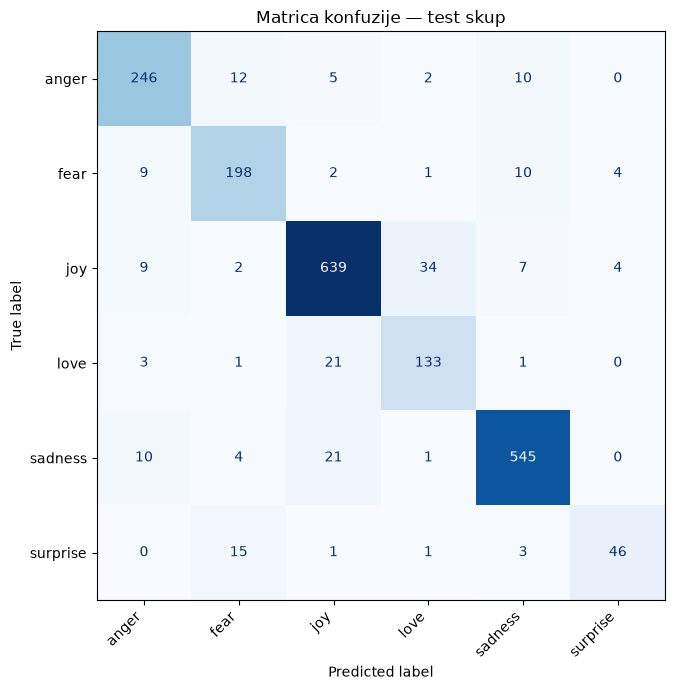

In [6]:
print(f'Evaluacija najboljeg modela: {best_model_name}')
print('Parametri:', {
    key: best_result[key]
    for key in ('embedding_dim', 'hidden_size', 'num_layers', 'dropout', 'learning_rate')
})
test_loss, test_accuracy, y_true, y_pred = print_evaluation(
    model, test_loader, label_names, device
)

label_indices = list(range(len(label_names)))
report = classification_report(
    y_true,
    y_pred,
    labels=label_indices,
    target_names=label_names,
    digits=4,
    zero_division=0,
)
(RESULTS_DIR / 'lstm_classification_report.txt').write_text(
    report, encoding='utf-8'
)
plt.gcf().savefig(
    RESULTS_DIR / 'lstm_confusion_matrix.png',
    bbox_inches='tight',
)
print(f'Rezultati su sačuvani u: {RESULTS_DIR}')

### Analiza rezultata

Najbolja LSTM konfiguracija koristi embedding dim `128`, hidden size `256`, `2` LSTM sloja, dropout `0.5` i learning rate `1e-3`, a najmanji validacioni loss postiže nakon 7 epoha.

Na test skupu model postiže Accuracy od `0.9035` i Macro F1 od `0.8659`.

Najbolji rezultati ostvareni su za klase `sadness`, `joy` i `anger`. Slabiji rezultati primećuju se kod manjinskih klasa `love` i `surprise`, što je očekivano zbog manje zastupljenosti ovih klasa u trening skupu.

Macro F1 je niži od Accuracy metrike jer svim klasama daje jednak značaj, uključujući i slabije zastupljene klase.